This notebook explores whether author gender correlates with average ratings on Goodreads. Using a dataset of 10,000 popular books, I infer author gender from first names and analyze rating patterns across gender categories, including authors who use initials only.

## Data Loading
Loading the goodbooks-10k dataset, a cleaned collection of 10,000 popular books sourced from Goodreads.

In [ ]:
import pandas as pd

# load the goodbooks-10k dataset
df = pd.read_csv('books.csv')

# preview first 5 rows to confirm successful load and inspect column structure
df.head()

,book_id,goodreads_book_id,best_book_id,work_id,books_count,isbn,isbn13,authors,original_publication_year,original_title,...,ratings_count,work_ratings_count,work_text_reviews_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5,image_url,small_image_url
0,1,2767052,2767052,2792775,272,439023483,9.780439e+12,Suzanne Collins,2008.0,The Hunger Games,...,4780653,4942365,155254,66715,127936,560092,1481305,2706317,https://images.gr-assets.com/books/1447303603m...,https://images.gr-assets.com/books/1447303603s...
1,2,3,3,4640799,491,439554934,9.780440e+12,"J.K. Rowling, Mary GrandPré",1997.0,Harry Potter and the Philosopher's Stone,...,4602479,4800065,75867,75504,101676,455024,1156318,3011543,https://images.gr-assets.com/books/1474154022m...,https://images.gr-assets.com/books/1474154022s...
2,3,41865,41865,3212258,226,316015849,9.780316e+12,Stephenie Meyer,2005.0,Twilight,...,3866839,3916824,95009,456191,436802,793319,875073,1355439,https://images.gr-assets.com/books/1361039443m...,https://images.gr-assets.com/books/1361039443s...
3,4,2657,2657,3275794,487,61120081,9.780061e+12,Harper Lee,1960.0,To Kill a Mockingbird,...,3198671,3340896,72586,60427,117415,446835,1001952,1714267,https://images.gr-assets.com/books/1361975680m...,https://images.gr-assets.com/books/1361975680s...
4,5,4671,4671,245494,1356,743273567,9.780743e+12,F. Scott Fitzgerald,1925.0,The Great Gatsby,...,2683664,2773745,51992,86236,197621,606158,936012,947718,https://images.gr-assets.com/books/1490528560m...,https://images.gr-assets.com/books/1490528560s...


## Data Exploration and Double-Checking Missing Values

In [ ]:
# examine column names, data types, and missing values across all 23 columns

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   book_id                    10000 non-null  int64  
 1   goodreads_book_id          10000 non-null  int64  
 2   best_book_id               10000 non-null  int64  
 3   work_id                    10000 non-null  int64  
 4   books_count                10000 non-null  int64  
 5   isbn                       9300 non-null   str    
 6   isbn13                     9415 non-null   float64
 7   authors                    10000 non-null  str    
 8   original_publication_year  9979 non-null   float64
 9   original_title             9415 non-null   str    
 10  title                      10000 non-null  str    
 11  language_code              8916 non-null   str    
 12  average_rating             10000 non-null  float64
 13  ratings_count              10000 non-null  int64  
 14  wo

In [ ]:
## looking at the distribution of average ratings across all 10,000 books
df['average_rating'].describe()

count    10000.000000
mean         4.002191
std          0.254427
min          2.470000
25%          3.850000
50%          4.020000
75%          4.180000
max          4.820000
Name: average_rating, dtype: float64

In [ ]:
## understanding the authors column, which contains a string of author names separated by commas for books with multiple authors
df['authors'].head(20)

0                                       Suzanne Collins
1                           J.K. Rowling, Mary GrandPré
2                                       Stephenie Meyer
3                                            Harper Lee
4                                   F. Scott Fitzgerald
5                                            John Green
6                                        J.R.R. Tolkien
7                                         J.D. Salinger
8                                             Dan Brown
9                                           Jane Austen
10                                      Khaled Hosseini
11                                        Veronica Roth
12              George Orwell, Erich Fromm, Celâl Üster
13                                        George Orwell
14    Anne Frank, Eleanor Roosevelt, B.M. Mooyaart-D...
15                           Stieg Larsson, Reg Keeland
16                                      Suzanne Collins
17              J.K. Rowling, Mary GrandPré, Ruf

## Feature Engineering
Extracting primary author and first name to prepare for gender inference. 
Some books list multiple authors — we isolate the first listed author only.

In [ ]:
## extracting the primary author (first name listed)
df['primary_author'] = df['authors'].str.split(',').str[0].str.strip()

# isolating the first name of the primary author for gender prediction using the Gender Guesser
df['first_name'] = df['primary_author'].str.split().str[0]

# checking the first 20 primary authors and their first names to confirm successful extraction
df[['primary_author', 'first_name']].head(20)

,primary_author,first_name
0,Suzanne Collins,Suzanne
1,J.K. Rowling,J.K.
2,Stephenie Meyer,Stephenie
3,Harper Lee,Harper
4,F. Scott Fitzgerald,F.
5,John Green,John
6,J.R.R. Tolkien,J.R.R.
7,J.D. Salinger,J.D.
8,Dan Brown,Dan
9,Jane Austen,Jane


## Gender Inference
Using the gender-guesser library to infer author gender from first names. 
Note: authors using initials only (e.g. J.K., J.R.R.) will return as 'unknown', which 
itself is a meaningful finding explored later.

In [ ]:
import gender_guesser.detector as gender

# creating an instance of the Gender Guesser detector
d = gender.Detector()

# apply gender detection to each first name
df['gender'] = df['first_name'].apply(lambda x: d.get_gender(x))

# review the distribution of gender categories assigned to the primary authors in the dataset
df['gender'].value_counts()

gender
male             4584
female           3403
unknown          1287
mostly_male       347
mostly_female     332
andy               47
Name: count, dtype: int64

Simplifying Gender Categories

In [ ]:
# consolidate mostly_male and mostly_female into male and female for cleaner analysis
df['gender_simplified'] = df['gender'].replace({
    'mostly_male': 'male',
    'mostly_female': 'female'
})

# compare average ratings across the simplified gender categories
df.groupby('gender_simplified')['average_rating'].describe()

,count,mean,std,min,25%,50%,75%,max
gender_simplified,,,,,,,,
andy,47.0,4.001915,0.221385,3.50,3.935,4.05,4.125,4.43
female,3735.0,3.977920,0.256613,2.67,3.820,3.99,4.160,4.76
male,4931.0,4.008416,0.245053,2.76,3.860,4.02,4.180,4.82
unknown,1287.0,4.048788,0.275902,2.47,3.880,4.09,4.250,4.77


Visualization
## Findings
### Finding 1: Male authors outnumber female authors in popular books
Of books where gender could be determined, male authors significantly outnumber 
female authors, which may suggest systemic differences in which books achieve popularity 
or visibility on Goodreads.

In [ ]:
# consistent color mapping across all visualizations
# steelblue = male, salmon = female
colors = {'male': 'steelblue', 'female': 'salmon'}

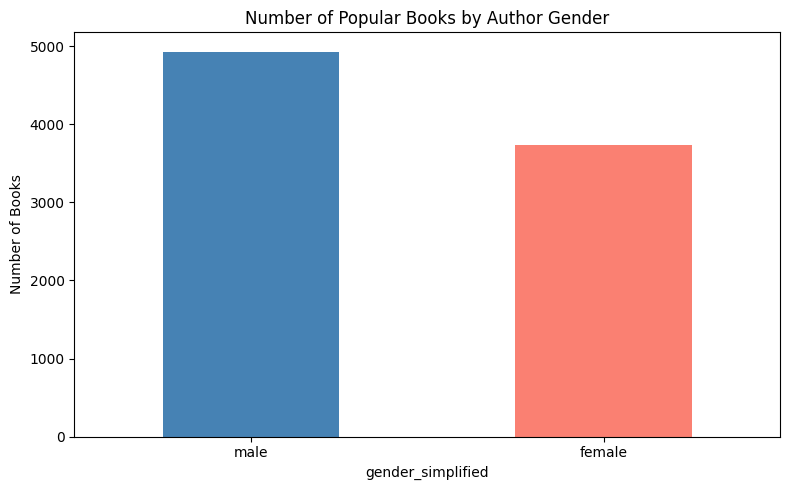

In [37]:
# count of authors by simplified gender category
# excludes unknown (largely initial-only authors) for cleaner representation
df[df['gender_simplified'].isin(['female', 'male'])]['gender_simplified'].value_counts().plot(
    kind='bar',
    color=['steelblue', 'salmon'],
    figsize=(8,5)
)
plt.title('Number of Popular Books by Author Gender')
plt.ylabel('Number of Books')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('gender_count.png')
plt.show()

### Finding 2: Male authors rate higher on average

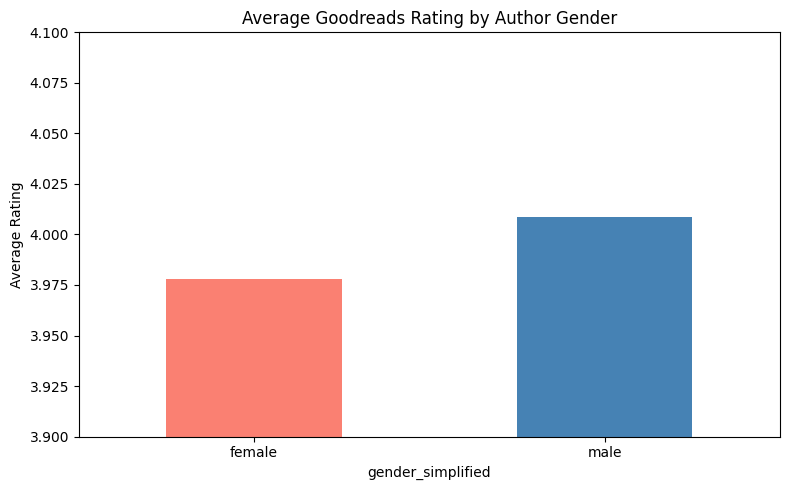

In [31]:
import matplotlib.pyplot as plt

# filter to male and female only for clean comparison
gender_ratings = df[df['gender_simplified'].isin(['male', 'female'])].groupby('gender_simplified')['average_rating'].mean()

# bar chart comparing average ratings by gender
gender_ratings.plot(kind='bar', 
                    color=['salmon', 'steelblue'],
                    figsize=(8,5))
plt.title('Average Goodreads Rating by Author Gender')
plt.ylabel('Average Rating')
plt.ylim(3.9, 4.1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('gender_ratings.png')
plt.show()

Initials Analysis
### Finding 3: Authors using intiials rate highest of all
Authors who obscure their first name with initials - a strategy that is encourage for female authors - rate significantly higher than both male and female authors with full first names.

In [ ]:
# identify initial-only authors
df['is_initials'] = df['first_name'].str.match(r'^[A-Z]\.$|^[A-Z]\.[A-Z]\.$')

# compare average ratings between initial-only and full-name authors
initials_rating = df.groupby('is_initials')['average_rating'].mean()
print(initials_rating)
print(df['is_initials'].value_counts())

is_initials
False    3.998802
True     4.066847
Name: average_rating, dtype: float64
is_initials
False    9502
True      498
Name: count, dtype: int64


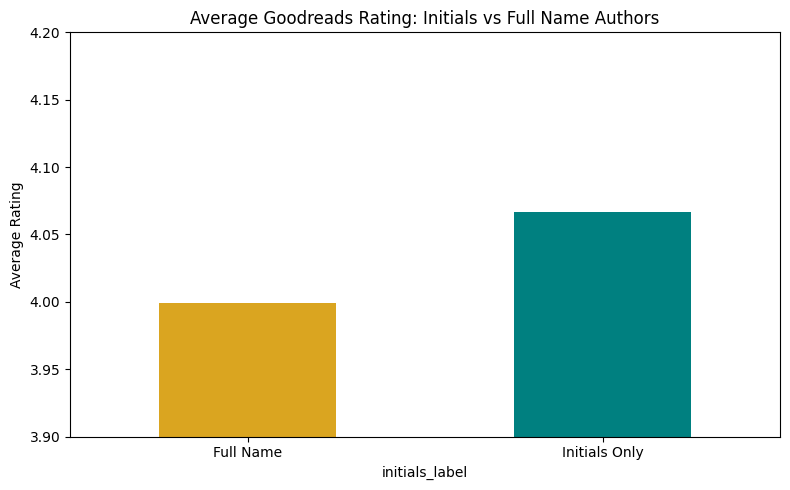

In [38]:
# visualize average rating comparison between initial-only and full-name authors
initials_labels = {True: 'Initials Only', False: 'Full Name'}
df['initials_label'] = df['is_initials'].map(initials_labels)

df.groupby('initials_label')['average_rating'].mean().plot(
    kind='bar',
    color=['goldenrod', 'teal'],
    figsize=(8,5)
)
plt.title('Average Goodreads Rating: Initials vs Full Name Authors')
plt.ylabel('Average Rating')
plt.ylim(3.9, 4.2)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('initials_ratings.png')
plt.show()

Save Cleaned Data
## Export
Saving the cleaned and enriched dataframe for future analysis.


In [39]:
# export cleaned dataset with gender columns added for future genre analysis
df.to_csv('goodreads_cleaned.csv', index=False)